In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 1000      # sweeps
SEED = 0    # dynamics RNG

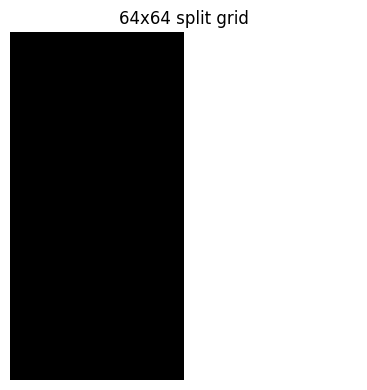

In [3]:
def make_split(size=64):
    """Left half 0 (black), right half 1 (white). Vertical boundary in the middle."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(64)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title("64x64 split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

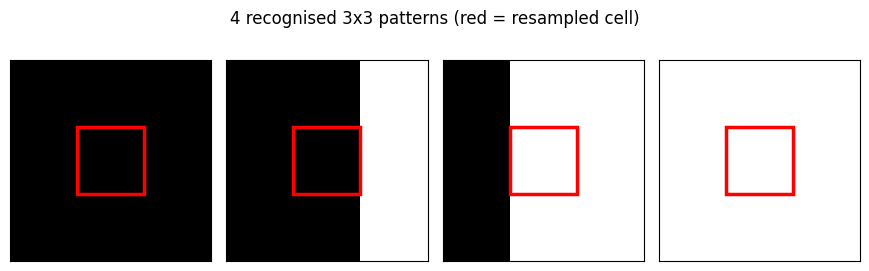

In [4]:
def win_key(w):
    """All nine cells of a 3x3 window, row-major."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """The set of complete 3x3 patterns that occur in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False,
                                   edgecolor="red", lw=2.5))
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns (red = resampled cell)")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [5]:
def step_seq(field, seen, rng):
    """Sequential sweep, sites in random order. For each cell, try both centre
    values; keep whichever make the whole 3x3 a recognised pattern.
    Both work -> coin flip. Neither works -> leave the cell alone."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    unresolved = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2].copy()
        ok = []
        for v in (0, 1):
            w[1, 1] = v
            if win_key(w) in seen:
                ok.append(v)
        if len(ok) == 1:
            field[r, c] = ok[0]
        elif len(ok) == 2:
            field[r, c] = int(rng.random() < 0.5)
        else:
            unresolved += 1
    return field, unresolved


def run(field, seen, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. `field` itself is never modified.
    Prints only when the numbers change."""
    rng = np.random.default_rng(seed)
    original = field.copy()
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, unresolved = step_seq(f, seen, rng)
        state = (int((f != original).sum()), unresolved)
        if verbose and state != prev:
            print(f"  sweep {t:5d}: differing = {state[0]:5d}   unresolved = {state[1]}")
            prev = state
    return f

In [6]:
final_clean = run(grid, seen, verbose=False)
print("fixed point:", np.array_equal(final_clean, grid))

fixed point: True


Noise 5.00%, unrecognised windows left alone:
  sweep     1: differing =   134   unresolved = 862
  sweep     2: differing =   134   unresolved = 408


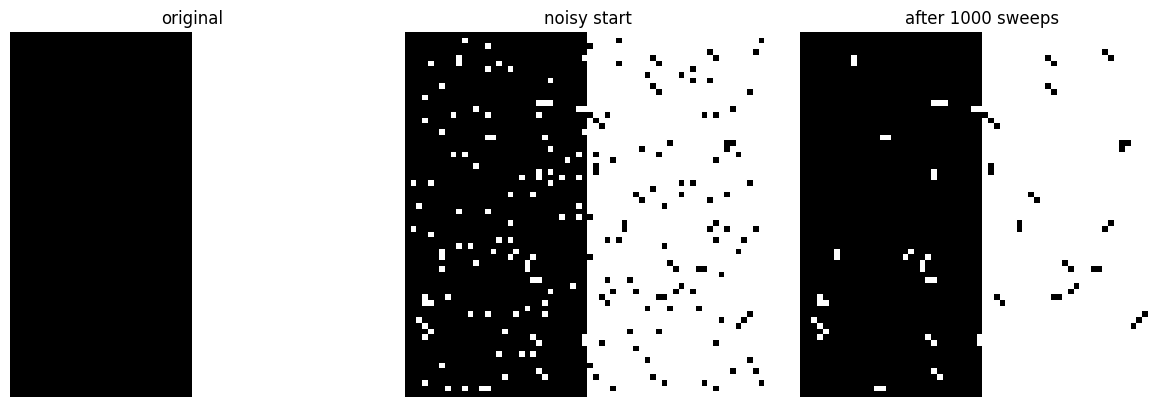

In [8]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.05
NOISE_SEED = 1

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
print(f"Noise {FRAC:.2%}, unrecognised windows left alone:")
final_noisy = run(noisy, seen)
plot_three(grid, noisy, final_noisy, N)